        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
Target    0
dtype: int64

Linear Regression
MSE : 2900.1936284934814
R2 Score : 0.4526027629719195

Best Ridge Alpha: 0.1
Ridge MSE : 2856.4868876706537
Ridge R

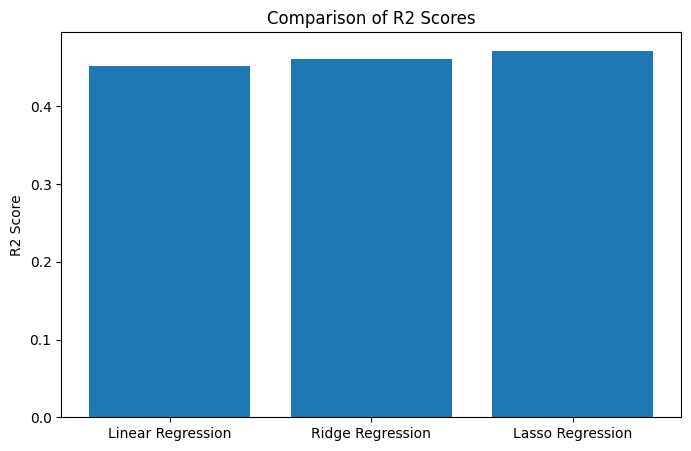

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=diabetes.feature_names)
df["Target"] = y

print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

linear = LinearRegression()

linear.fit(X_train, y_train)

y_pred_linear = linear.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("\nLinear Regression")
print("MSE :", mse_linear)
print("R2 Score :", r2_linear)

ridge = Ridge()

parameters = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_cv = GridSearchCV(
    ridge,
    parameters,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nBest Ridge Alpha:", ridge_cv.best_params_['alpha'])
print("Ridge MSE :", mse_ridge)
print("Ridge R2 :", r2_ridge)

lasso = Lasso(max_iter=10000)

parameters = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso_cv = GridSearchCV(
    lasso,
    parameters,
    cv=5,
    scoring='neg_mean_squared_error'
)

lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_

y_pred_lasso = best_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nBest Lasso Alpha:", lasso_cv.best_params_['alpha'])
print("Lasso MSE :", mse_lasso)
print("Lasso R2 :", r2_lasso)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [mse_linear, mse_ridge, mse_lasso],
    'R2 Score': [r2_linear, r2_ridge, r2_lasso]
})

print("\nComparison of Models")
print(results)

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['R2 Score'])

plt.title("Comparison of R2 Scores")
plt.ylabel("R2 Score")

plt.show()